<div style='background: linear-gradient(135deg, #f65b5b 0%, #d5d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>EDA</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

<style>
    body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
    h1, h2, h3, h4 { font-weight: 700; color: #1e3c72; }
    .concept-box { background-color: #f8f9fa; border-left: 5px solid #1e3c72; padding: 15px; margin: 15px 0; font-size: 15px; }
    .action-box { background-color: #e8f5e9; border-left: 5px solid #43a047; padding: 15px; margin: 15px 0; font-size: 15px; }
    .warning-box { background-color: #fff3e0; border-left: 5px solid #ff9800; padding: 15px; margin: 15px 0; font-size: 15px; }
</style>

# Philosophie de cette analyse

Les algorithmes basés sur la distance euclidienne reposent sur trois postulats fondamentaux :
1. Absence de valeurs manquantes (la distance ne peut être calculée).
2. Sensibilité extrême aux outliers (les centroïdes sont "tirés" par les valeurs extrêmes).
3. Isotropie et Échelle (une variable non standardisée ou fortement asymétrique écrasera toutes les autres ; des variables très corrélées doubleront artificiellement leur poids).

L'objectif de ce notebook est de diagnostiquer et d'agir pour construire le dataset finale

# Initialisation de l'Environnement

In [70]:
import sys
from pathlib import Path

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.config import paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy.stats import skew
import geopandas as gpd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)


# Chargement et Structuration du Dataset


In [71]:
df = pd.read_csv(paths.DATA_DIR / "merged_data.csv")


with open(paths.CONFIG_DIR / "variables.yaml", 'r') as file:
    config = yaml.safe_load(file)

added_vars = []
for source, details in config['sources'].items():
    if 'variables' in details:
        added_vars.extend(list(details['variables'].values()))
added_vars = [var for var in added_vars if var in df.columns]

id_vars = ['country', 'iso_code']
original_vars = [col for col in df.columns if col not in added_vars and col not in id_vars]

# Séparation fonctionnelle
df_features = df.drop(columns=id_vars).copy()
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

print(f"Dimension de l'espace de base : {df.shape}")
print(f"Variables d'analyse retenues : {len(numeric_cols)}")


Dimension de l'espace de base : (167, 24)
Variables d'analyse retenues : 22


In [72]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'iso_code',
       'child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence',
       'life_expectancy', 'maternal_mortality', 'physicians_per_1000',
       'tb_incidence', 'vaccination_dpt', 'social_poverty_mpi',
       'social_literacy', 'social_poverty_2_15', 'social_schooling',
       'social_undernourishment'],
      dtype='str')

#  Analyse Exploratoire Globale

## Asymétrie des distributions

Le skewness (ou coefficient d'asymétrie de Fisher) mesure la déviation d'une distribution par rapport à la symétrie d'une loi normale 
La skewness mesure l’asymétrie d’une distribution par rapport à sa moyenne.

$$
\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}
$$

Interprétation
- **Skewness ≈ 0** → distribution symétrique  
- **Skewness > 0** → longue queue à droite (asymétrie positive)  
- **Skewness < 0** → longue queue à gauche (asymétrie négative)

Une fois que vous avez calculé l'asymétrie, vous pouvez classer l'ampleur de l'asymétrie par catégorie :

(-0,5, 0,5) - faible ou approximativement symétrique.
(-1, -0,5) U (0,5, 1) - modérément asymétrique.
Au-delà de -1 et 1 - Très asymétrique.


Source :https://www.datacamp.com/fr/tutorial/understanding-skewness-and-kurtosis

Source : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html


In [73]:
#  Calcul de l'asymétrie  pour repérer les distributions déséquilibrées
skewness = df[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("Top 20 des variables les plus asymétriques :")
print(skewness.head(20))

Top 20 des variables les plus asymétriques :
inflation                     5.107640
hiv_prevalence                4.242149
exports                       2.423800
tb_incidence                  2.376273
income                        2.211386
maternal_mortality            2.204360
gdpp                          2.198079
imports                       1.888120
social_undernourishment       1.718870
child_mortality               1.701214
social_poverty_2_15           1.531280
child_mort                    1.437710
total_fer                     0.958383
social_poverty_mpi            0.769062
health_expenditure_pct_gdp    0.759786
health                        0.699391
physicians_per_1000           0.481052
life_expectancy              -0.691520
life_expec                   -0.962252
social_literacy              -1.090992
dtype: float64


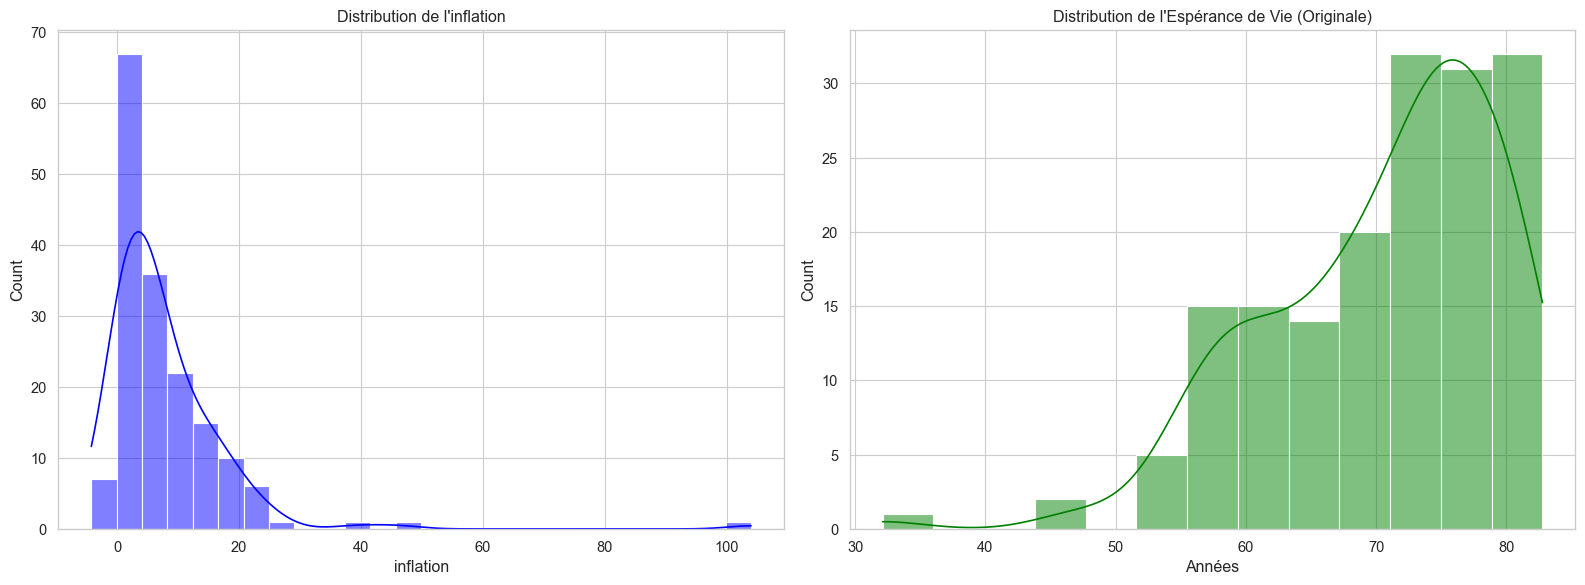

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['inflation'], kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribution de l'inflation")
axes[0].set_xlabel("inflation")

sns.histplot(df['life_expec'], kde=True, ax=axes[1], color='green')
axes[1].set_title("Distribution de l'Espérance de Vie (Originale)")
axes[1].set_xlabel("Années")

plt.tight_layout()
plt.show()

## Transformation log pour les variables fortement asymetriques

In [75]:
# On fixe un seuil d'asymétrie à 1 (empirique)
skewed_vars = skewness[skewness > 1].index.tolist()
print(f"\nVariables nécessitant une transformation Log : {skewed_vars}")

df_transformed = df.copy()
for var in skewed_vars:
    # np.log1p évite les erreurs avec les valeurs à 0 (log(1+x))
    df_transformed[f"{var}_log"] = np.log1p(df_transformed[var])
    # On met à jour nos listes de variables
    numeric_cols.append(f"{var}_log")
    numeric_cols.remove(var)


Variables nécessitant une transformation Log : ['inflation', 'hiv_prevalence', 'exports', 'tb_incidence', 'income', 'maternal_mortality', 'gdpp', 'imports', 'social_undernourishment', 'child_mortality', 'social_poverty_2_15', 'child_mort']


c:\Users\HP\Desktop\temp\TODO\SEMESTRE_2\ML2\projet\env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


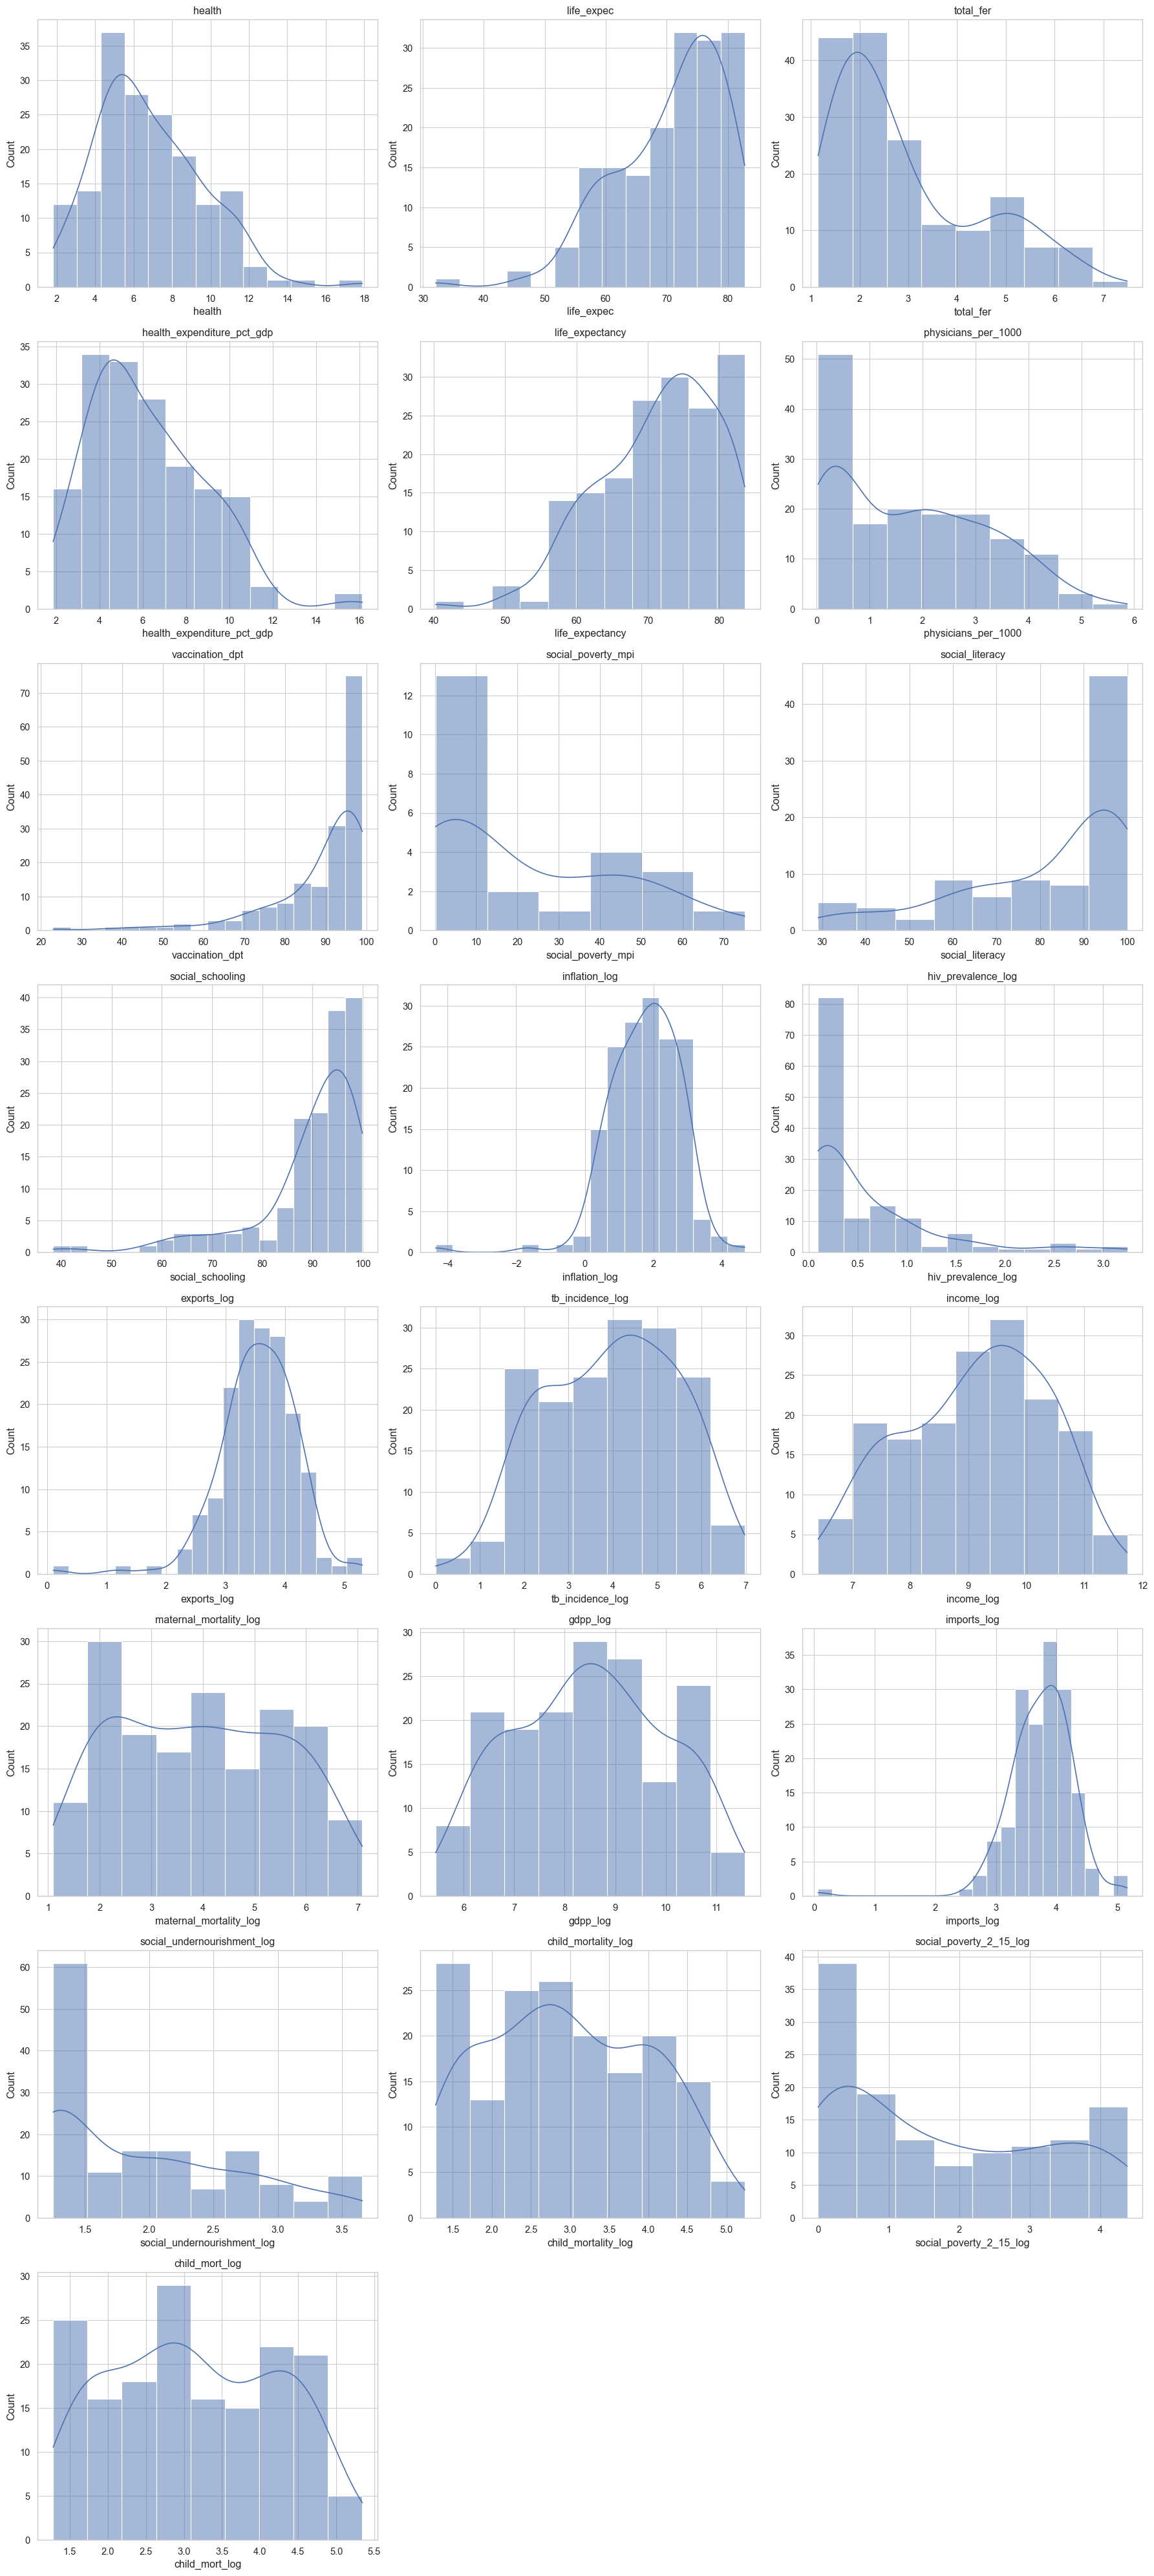

In [76]:
plt.figure(figsize=(18, 5 * ((len(numeric_cols) + 2)//3)))

for i, col in enumerate(numeric_cols, 1):

    plt.subplot((len(numeric_cols) + 2)//3, 3, i)

    sns.histplot(df_transformed[col], kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

L’analyse des distributions montre une forte hétérogénéité entre les variables socio-économiques et sanitaires. Plusieurs indicateurs bruts présentent une asymétrie positive marquée, notamment `health`, `health_expenditure_pct_gdp`, `physicians_per_1000`, `social_poverty_mpi` et surtout `vaccination_dpt`, dont la masse est concentrée sur des valeurs élevées avec une longue queue vers les faibles couvertures vaccinales. Cette structure traduit l’existence de groupes de pays très contrastés : quelques pays fortement défavorisés coexistent avec une majorité de pays intermédiaires ou relativement développés. À l’inverse, certaines variables comme `life_expec`, `social_literacy` et `social_schooling` apparaissent plus concentrées et relativement unimodales, suggérant des indicateurs plus stables et moins dominés par des valeurs extrêmes. Sans correction, ces déséquilibres auraient tendance à biaiser les distances euclidiennes utilisées dans des méthodes comme K-means Clustering.

Les transformations logarithmiques appliquées aux variables fortement asymétriques ont globalement amélioré la structure des distributions. Les variables transformées telles que `inflation_log`, `exports_log`, `income_log`, `gdpp_log` et `imports_log` présentent désormais des formes beaucoup plus proches d’une distribution centrée et exploitable pour le clustering. La compression des valeurs extrêmes réduit l’influence disproportionnée des pays atypiques et favorise une contribution plus équilibrée des différentes dimensions socio-économiques dans le calcul des distances. Certaines variables restent néanmoins partiellement asymétriques après transformation, notamment `hiv_prevalence_log`, `social_undernourishment_log` et `social_poverty_2_15_log`, ce qui reflète probablement des phénomènes structurels réels plutôt qu’un simple problème d’échelle.


# Diagnostic et traitement des valeurs manquantes


## Diagnostic des NA

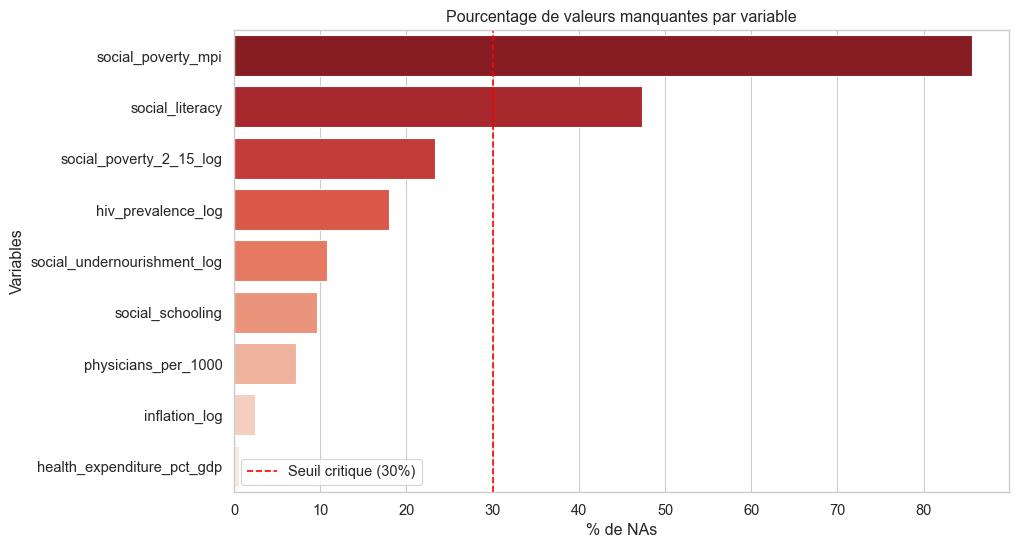

In [77]:
#  Calcul du pourcentage de NAs par variable
missing_percentage = (df_transformed[numeric_cols].isnull().sum() / len(df_transformed)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

#  Visualisation des valeurs manquantes
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index,
    hue=missing_percentage.index,   # associer la palette aux variables
    palette="Reds_r",
    dodge=False,                    # évite les barres côte à côte
    legend=False                    # pas besoin de légende
)
plt.title("Pourcentage de valeurs manquantes par variable")
plt.xlabel("% de NAs")
plt.ylabel("Variables")
plt.axvline(x=30, color='red', linestyle='--', label='Seuil critique (30%)')
plt.legend()
plt.show()



Certaines présentent un taux de données absentes faible et raisonnablement gérable (`inflation_log`, `health_expenditure_pct_gdp`, `physicians_per_1000`, `social_schooling`), tandis que d’autres souffrent d’un déficit d’information beaucoup plus problématique. Le cas le plus critique est `social_poverty_mpi`, avec plus de 80 % de valeurs manquantes, largement au-dessus du seuil critique de 30 %. Cela suggère soit une faible couverture statistique internationale de l’indicateur MPI, soit une indisponibilité structurelle pour de nombreux pays.une telle variable risque d’introduire un biais important : l’information observée ne représente probablement qu’un sous-ensemble particulier de pays, souvent les pays en développement. L’utiliser naïvement pourrait donc déformer les clusters ou réduire fortement la taille effective du dataset après suppression des lignes incomplètes.

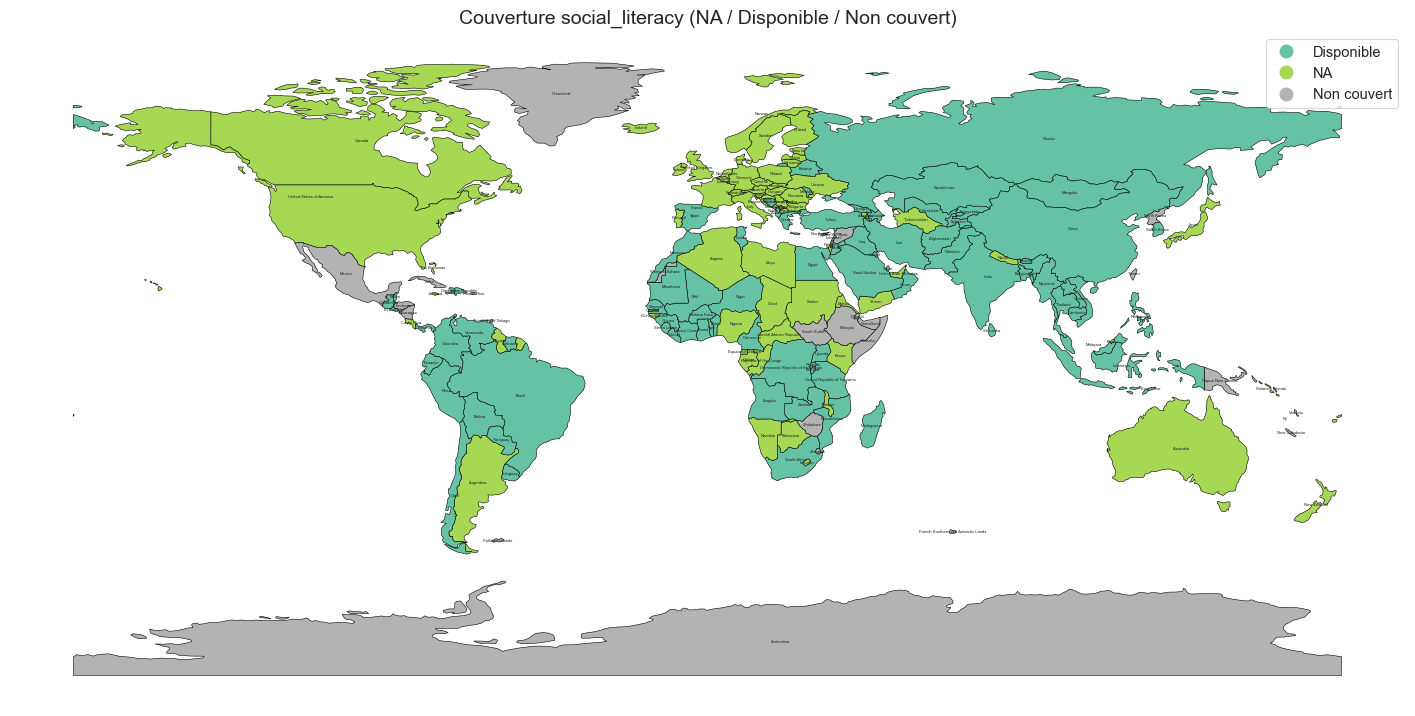

In [78]:
# =========================
# Pays depuis le dataset
# =========================
na_countries = set(df_transformed.loc[
    df_transformed["social_literacy"].isna(),
    "iso_code"
])

available_countries = set(df_transformed.loc[
    df_transformed["social_literacy"].notna(),
    "iso_code"
])

# =========================
# Carte mondiale
# =========================
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# =========================
# Typologie
# =========================
world["status"] = "Non couvert"
world.loc[world["ADM0_A3"].isin(available_countries), "status"] = "Disponible"
world.loc[world["ADM0_A3"].isin(na_countries), "status"] = "NA"

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(18, 10))

world.plot(
    column="status",
    legend=True,
    cmap="Set2",
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

# =========================
# Ajout des noms de pays
# =========================
for _, row in world.iterrows():
    if row["geometry"].centroid.is_empty:
        continue
    x, y = row["geometry"].centroid.x, row["geometry"].centroid.y
    ax.text(
        x, y,
        row["ADMIN"],
        fontsize=3,
        ha="center",
        va="center"
    )

ax.set_title("Couverture social_literacy (NA / Disponible / Non couvert)", fontsize=14)
ax.axis("off")

plt.show()

La variable social_literacy présente une couverture fortement incomplète, avec une proportion élevée de valeurs manquantes (> 40%). La répartition des NA n’est pas aléatoire : elle touche de manière structurelle plusieurs ensembles de pays (notamment en Afrique subsaharienne et dans certaines régions en développement), ce qui introduit un risque de biais de sélection important. La variable n’est donc pas seulement partiellement observée, elle est aussi potentiellement non représentative à l’échelle mondiale.

In [79]:
threshold_var = 40 
cols_to_drop = missing_percentage[missing_percentage > threshold_var].index.tolist()
print(f"Variables supprimées car trop de NAs (> {threshold_var}%) : {cols_to_drop}")

df_cleaned = df_transformed.drop(columns=cols_to_drop)

# Mise à jour des variables retenues
final_numeric_cols =[col for col in numeric_cols if col not in cols_to_drop]

Variables supprimées car trop de NAs (> 40%) : ['social_poverty_mpi', 'social_literacy']


## Carte NA par pays

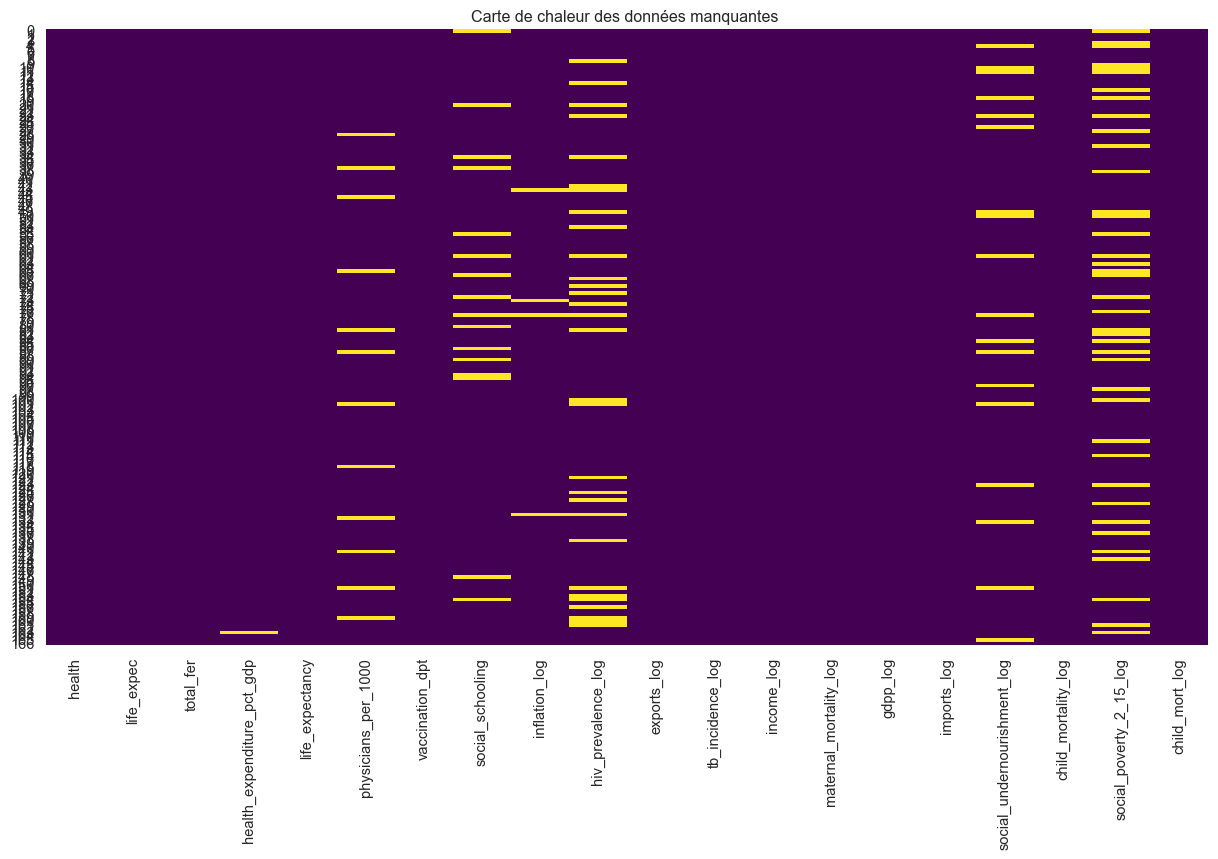

In [80]:
# Visualisation de la structure des données manquantes
plt.figure(figsize=(15, 8))
sns.heatmap(df_cleaned[final_numeric_cols].isnull(), yticklabels=True, cbar=False, cmap='viridis')
plt.title("Carte de chaleur des données manquantes ")
plt.show()

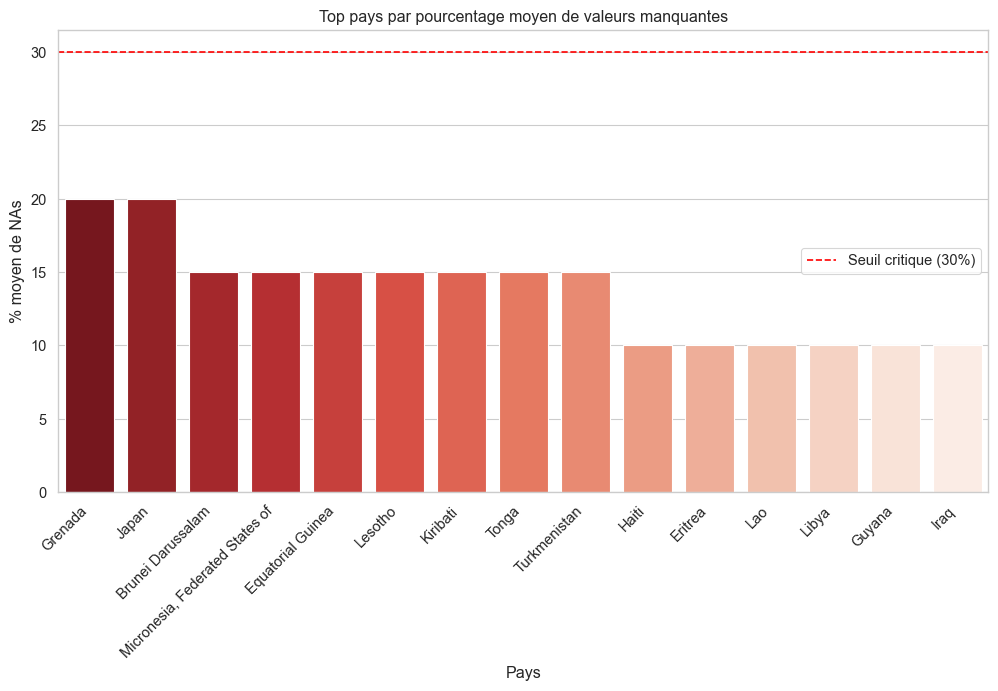

In [81]:
# Calcul du % moyen de NAs par ISO
missing_by_iso = (
    df_cleaned.groupby(["iso_code", "country"])[final_numeric_cols]
    .apply(lambda x: x.isnull().mean() * 100)
)

missing_mean_iso = missing_by_iso.mean(axis=1).sort_values(ascending=False)

# Top 15 pays avec le plus de NAs
top_missing_iso = missing_mean_iso.head(15).reset_index()

# Visualisation avec noms de pays
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_missing_iso,
    x="country", 
    y=0,  # la colonne des valeurs calculées
    hue="country",   # associer la palette aux pays
    palette="Reds_r",
    dodge=False,
    legend=False
)
plt.title("Top pays par pourcentage moyen de valeurs manquantes")
plt.xlabel("Pays")
plt.ylabel("% moyen de NAs")
plt.axhline(y=30, color='red', linestyle='--', label='Seuil critique (30%)')
plt.legend()
plt.xticks(rotation=45, ha="right")  # rotation pour lisibilité
plt.show()


Dans le classement par pays, on observe que certains États comme Grenade, le Japon ou Brunei présentent des taux moyens de valeurs manquantes relativement élevés (autour de 20%). Cela signifie que, pour ces pays, une proportion importante des indicateurs socio‑économiques ou sanitaires n’est pas renseignée. Même si le seuil critique fixé à 30% n’est pas atteint, ces manques peuvent limiter la fiabilité des analyses comparatives ou des modèles statistiques qui incluent ces pays. En pratique, cela suggère soit de compléter les données par des sources externes, soit d’envisager des techniques d’imputation, soit encore d’exclure certains pays selon la rigueur exigée par l’étude.

La carte de chaleur des données manquantes apporte une vision plus fine : elle montre que les absences ne sont pas uniformes. Certaines variables comme les dépenses de santé, la prévalence du VIH ou les indicateurs de pauvreté présentent des lacunes marquées dans plusieurs pays, tandis que d’autres (par exemple l’espérance de vie ou le PIB log-transformé) sont mieux renseignées. Cette hétérogénéité est cruciale : elle indique que les problèmes de complétude ne viennent pas seulement de certains pays, mais aussi de la nature des indicateurs eux‑mêmes. Les variables liées à la santé publique ou aux statistiques sociales semblent particulièrement vulnérables.

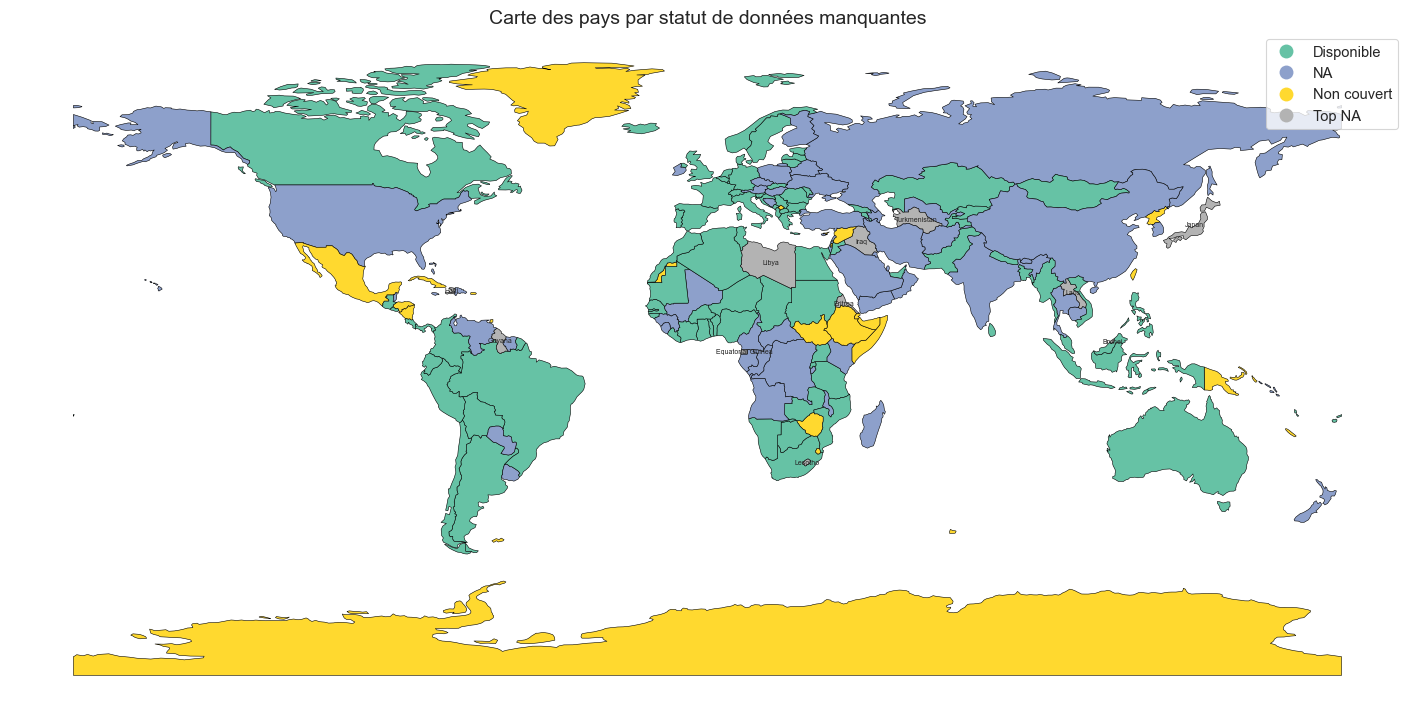

In [82]:
import geopandas as gpd
import matplotlib.pyplot as plt

# =========================
# Calcul des % de NAs par pays
# =========================
missing_by_country = (
    df_cleaned.groupby("iso_code")[final_numeric_cols]
    .apply(lambda x: x.isnull().mean() * 100)
)
missing_mean_country = missing_by_country.mean(axis=1).sort_values(ascending=False)

# Sets de pays
top15_iso = set(missing_mean_country.head(15).index)
na_iso = set(missing_mean_country[missing_mean_country > 0].index) - top15_iso
available_iso = set(missing_mean_country[missing_mean_country == 0].index)

# =========================
# Carte mondiale
# =========================
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# =========================
# Typologie
# =========================
world["status"] = "Non couvert"
world.loc[world["ADM0_A3"].isin(available_iso), "status"] = "Disponible"
world.loc[world["ADM0_A3"].isin(na_iso), "status"] = "NA"
world.loc[world["ADM0_A3"].isin(top15_iso), "status"] = "Top NA"

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(18, 10))

world.plot(
    column="status",
    legend=True,
    cmap="Set2",
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

# =========================
# Ajout des noms de pays (seulement Top NA)
# =========================
for _, row in world.iterrows():
    if row["status"] == "Top NA":
        if row["geometry"].centroid.is_empty:
            continue
        x, y = row["geometry"].centroid.x, row["geometry"].centroid.y
        ax.text(
            x, y,
            row["ADMIN"],
            fontsize=5,
            ha="center",
            va="center"
        )

ax.set_title("Carte des pays par statut de données manquantes", fontsize=14)
ax.axis("off")

plt.show()


L’analyse des pays en tête du classement des valeurs manquantes en 2014 montre une diversité de profils qui partagent pourtant des fragilités communes dans la collecte statistique. Grenade, le Japon ou Brunei apparaissent dans le top, mais pour des raisons différentes : dans les petits États insulaires (Grenade, Micronésie, Kiribati, Tonga), la capacité statistique est limitée et les enquêtes ne sont pas systématiques chaque année. Dans des pays plus développés comme le Japon, certains indicateurs spécifiques (par exemple la prévalence du VIH ou la mortalité maternelle) ne sont pas collectés ou publiés régulièrement, car jugés peu pertinents ou sensibles. D’autres pays comme la Libye, l’Irak ou l’Érythrée souffrent de contextes politiques instables ou de conflits, ce qui rend la transmission des données sanitaires et sociales particulièrement difficile.  

Cette hétérogénéité souligne que les NAs ne traduisent pas une seule cause, mais une combinaison de facteurs : faible capacité statistique, choix méthodologiques des institutions internationales, ou impossibilité matérielle de collecter des données en zones de crise. Les pays du top 15 sont donc des cas critiques qui nécessitent une attention particulière dans l’analyse : soit par imputation ciblée, soit par restriction de l’échantillon, soit encore par une pondération spécifique lors du clustering. En pratique, leur présence dans le top des NAs rappelle que la robustesse des modèles dépend autant de la qualité des données que des méthodes statistiques employées pour compenser ces manques.

## La cause des NA ?


### Analyse

In [83]:
# Nombre de pays concernés par chaque variable
na_countries_per_var = {
    col: df_cleaned.loc[df_cleaned[col].isnull(), "iso_code"].unique().tolist()
    for col in final_numeric_cols
}

for var, countries in na_countries_per_var.items():
    if len(countries) !=0 :
        print(f"\nVariable : {var}")
        print(f"Pays avec NAs ({len(countries)}): {countries}")



Variable : health_expenditure_pct_gdp
Pays avec NAs (1): ['VEN']

Variable : physicians_per_1000
Pays avec NAs (12): ['CMR', 'COD', 'DOM', 'GUY', 'KIR', 'LSO', 'FSM', 'PRY', 'SLE', 'VCT', 'TON', 'USA']

Variable : social_schooling
Pays avec NAs (16): ['AFG', 'BIH', 'CHN', 'COD', 'GAB', 'GRD', 'HTI', 'IRQ', 'JPN', 'KEN', 'LBN', 'LBY', 'MDG', 'MWI', 'THA', 'TKM']

Variable : inflation_log
Pays avec NAs (4): ['CZE', 'IRL', 'JPN', 'SYC']

Variable : hiv_prevalence_log
Pays avec NAs (30): ['AUT', 'BLR', 'BIH', 'BRN', 'CHN', 'CYP', 'CZE', 'GNQ', 'FIN', 'GRD', 'HUN', 'IND', 'IRN', 'ISR', 'JPN', 'KIR', 'MUS', 'FSM', 'POL', 'RUS', 'WSM', 'SYC', 'KOR', 'TON', 'TUR', 'TKM', 'UKR', 'USA', 'URY', 'UZB']

Variable : social_undernourishment_log
Pays avec NAs (18): ['ATG', 'BHS', 'BHR', 'BTN', 'BRN', 'BDI', 'GNQ', 'ERI', 'GRD', 'JPN', 'LAO', 'LSO', 'MDV', 'FSM', 'QAT', 'SGP', 'TON', 'YEM']

Variable : social_poverty_2_15_log
Pays avec NAs (39): ['AFG', 'AGO', 'ATG', 'AZE', 'BHS', 'BHR', 'BLZ', 'BTN',

Les indicateurs financiers tels que **health_expenditure_pct_gdp** et **inflation_log** apparaissent globalement robustes, avec respectivement une seule omission (Venezuela) et quatre absences ponctuelles (République tchèque, Irlande, Japon, Seychelles). Ces manques semblent relever de causes techniques ou conjoncturelles, et ne portent pas de signification particulière sur la réalité socio‑économique des pays concernés. En revanche, les variables liées aux infrastructures sanitaires et éducatives, comme **physicians_per_1000** et **social_schooling**, présentent des lacunes plus marquées (12 à 16 pays). Ici, le NA peut être interprété comme une information : il signale souvent une faible capacité statistique ou un contexte de crise qui empêche la collecte, ce qui est en soi révélateur des fragilités institutionnelles.  

Les indicateurs sociaux et de santé publique sont les plus problématiques. La variable **hiv_prevalence_log** compte 30 pays manquants, incluant des puissances industrielles (USA, Japon, Russie) et des pays en développement. Dans ce cas, l’absence n’est pas neutre : elle peut traduire une **incidence très faible** (donc jugée non prioritaire), ou au contraire une **politique de confidentialité** stricte. De même, **social_undernourishment_log**.

La variable social_poverty_2_15_log est la plus lacunaire avec 39 pays manquants. Ce déficit d'information est particulièrement critique puisqu'il concerne des pays aux profils très variés, allant des pétromonarchies (Koweït, Arabie Saoudite) à des zones de forte instabilité (Afghanistan, Centrafrique). Pour les nations à haut revenu, l'absence de données sur le seuil de pauvreté extrême reflète souvent l'inadaptation de cet indicateur à leur contexte économique. Pour les autres, cela souligne les limites structurelles des appareils statistiques nationaux.


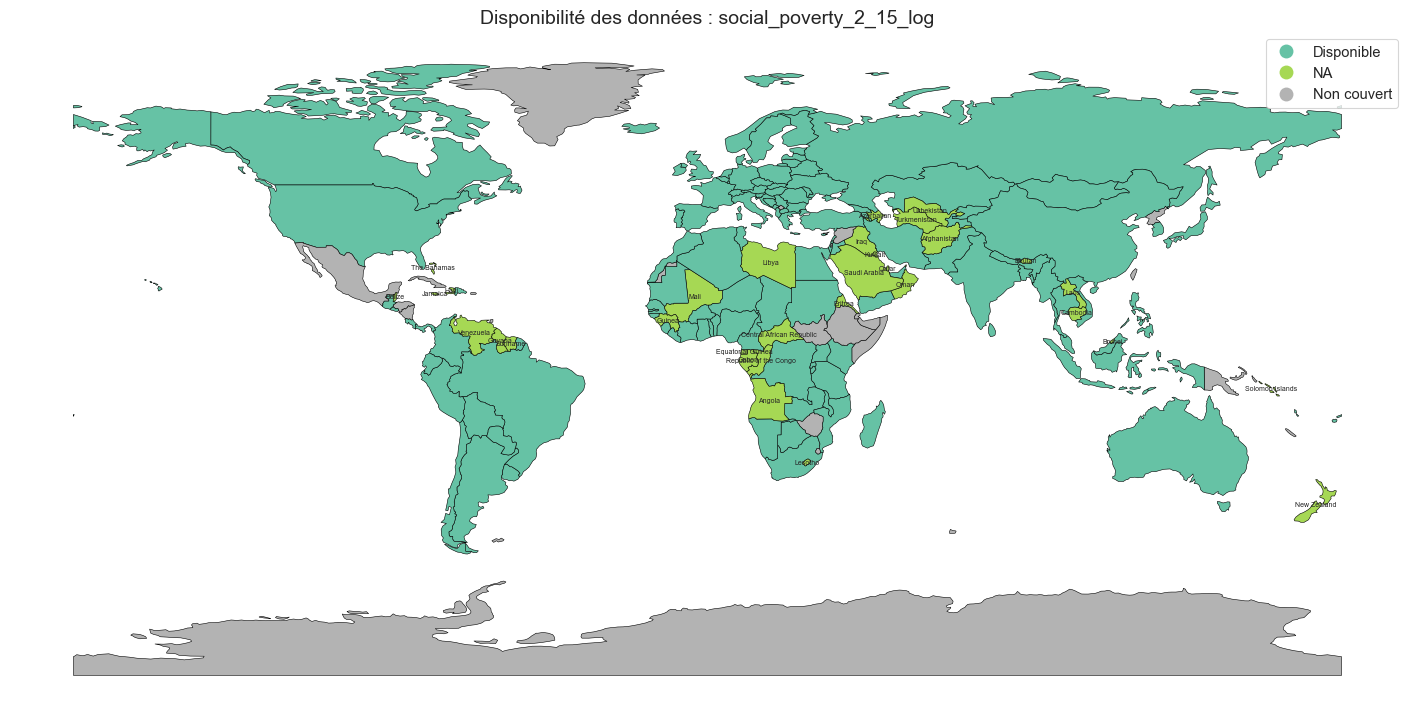

In [84]:
# =========================
# Statut des pays pour la variable social_poverty_2_15_log
# =========================
na_iso = set(df_cleaned.loc[df_cleaned["social_poverty_2_15_log"].isnull(), "iso_code"])
available_iso = set(df_cleaned.loc[df_cleaned["social_poverty_2_15_log"].notnull(), "iso_code"])

# =========================
# Carte mondiale
# =========================
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# =========================
# Typologie
# =========================
world["status"] = "Non couvert"
world.loc[world["ADM0_A3"].isin(available_iso), "status"] = "Disponible"
world.loc[world["ADM0_A3"].isin(na_iso), "status"] = "NA"

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(18, 10))

world.plot(
    column="status",
    legend=True,
    cmap="Set2",
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

# =========================
# Ajout des noms de pays NA
# =========================
for _, row in world.iterrows():
    if row["status"] == "NA":
        if row["geometry"].centroid.is_empty:
            continue
        x, y = row["geometry"].centroid.x, row["geometry"].centroid.y
        ax.text(
            x, y,
            row["ADMIN"],
            fontsize=5,
            ha="center",
            va="center"
        )

ax.set_title("Disponibilité des données : social_poverty_2_15_log", fontsize=14)
ax.axis("off")

plt.show()


La carte de disponibilité de l’indicateur **social_poverty_2_15_log** met en évidence une couverture très inégale à l’échelle mondiale : si la majorité des pays disposent de données exploitables, un nombre significatif d’États — notamment en Afrique subsaharienne, dans les Caraïbes, au Moyen‑Orient et parmi certains petits États insulaires — apparaissent en **NA**, traduisant une absence de collecte ou de publication. Cette répartition n’est pas aléatoire : elle reflète des **capacités statistiques limitées**, des **choix politiques de non‑production** ou encore des **contraintes méthodologiques** propres à certains contextes. L’absence elle‑même devient donc une information : elle signale des zones où la pauvreté n’est pas mesurée ou rendue publique, ce qui doit être pris en compte dans l’interprétation des résultats et dans la robustesse des analyses comparatives.

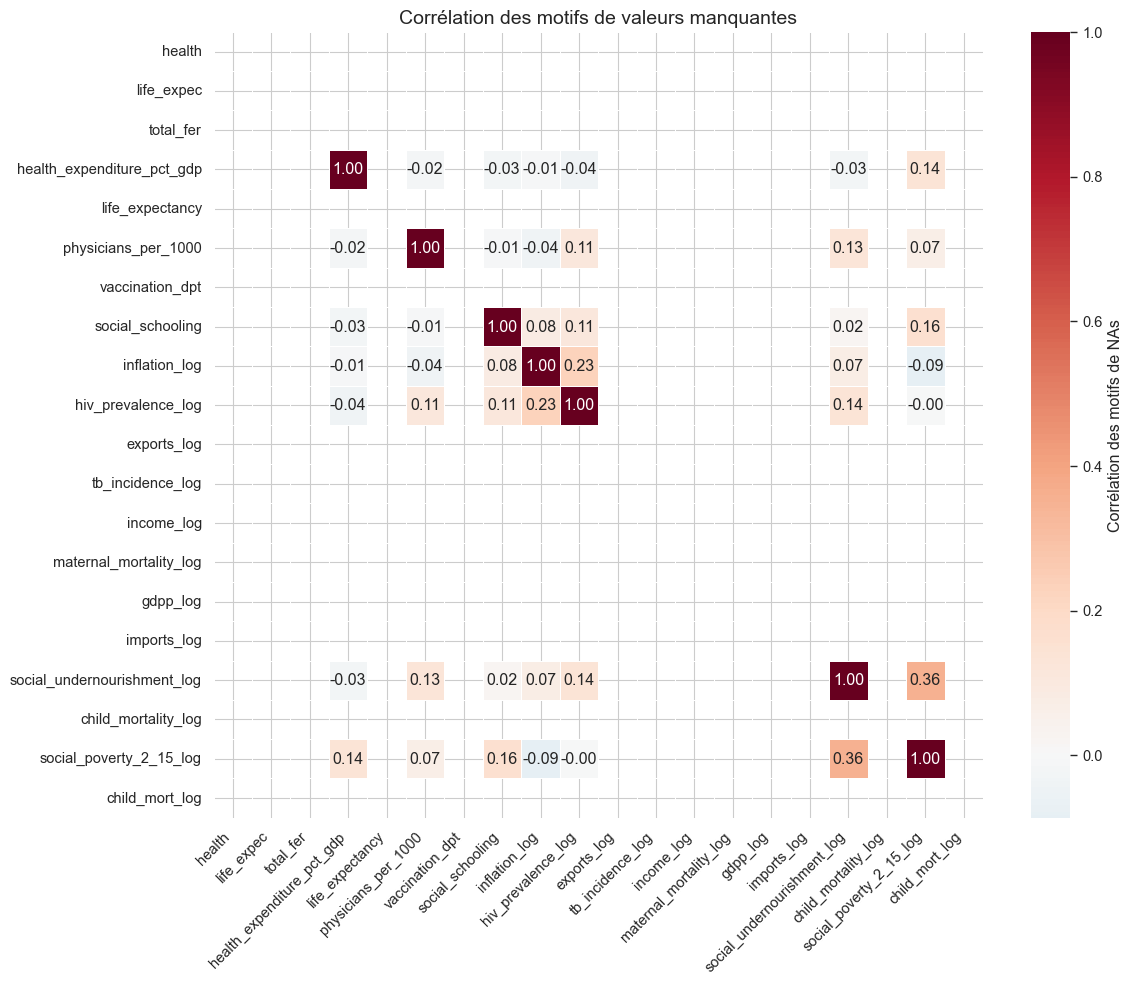

In [85]:
# Matrice binaire des NAs
na_matrix = df_cleaned[final_numeric_cols].isnull().astype(int)

# Corrélation entre patterns de NAs
na_corr = na_matrix.corr()

# Heatmap lisible
plt.figure(figsize=(12, 10))
sns.heatmap(
    na_corr,
    annot=True,          # afficher les coefficients
    fmt=".2f",           # format des nombres
    cmap="RdBu_r",       # palette rouge/bleu intuitive
    center=0,            # centrer la palette sur 0
    linewidths=0.5,      # lignes séparatrices
    cbar_kws={"label": "Corrélation des motifs de NAs"}
)
plt.title("Corrélation des motifs de valeurs manquantes", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Les coefficients non nuls observés (ex: social_undernourishment_log et social_poverty_2_15_log à $0.355$) sont trop faibles pour affirmer une dépendance structurelle forte. Une corrélation proche de $1$ indiquerait que si une donnée est manquante pour l'une, elle l'est systématiquement pour l'autre (Missing Completely At Random ou Missing At Random de manière jointe). Ici, les absences semblent dispersées.

### Recommandations et conclusion

- Pays en crise ou à faible capacité statistique : Les NAs s'accumulent sur les variables sociales et d'infrastructure (social_schooling, physicians_per_1000).

- Pays développés : Les NAs sur des variables comme hiv_prevalence_log ou social_poverty_2_15_log traduisent une non-pertinence de l'indicateur ou une prévalence proche de zéro.

> La concluion ici est que la presence de NA n'est pas systematiquement lié à une cause unique .aussi nous considérons que la présence de NA n'est pas une information en soit.
Nous allons donc utiliser une imputation multivariée basée sur les plus proches voisins (KNN Imputer). Le KNN cherchera les pays ayant des profils socio-économiques similaires (sur les variables disponibles) pour déduire la valeur manquante.



## Stratégie d'Imputation des NA


La stratégie mise en place consiste à évaluer plusieurs algorithmes d’imputation en parallèle afin de mesurer leur capacité à préserver la structure statistique des données. Pour cela, les métriques de référence (variance et corrélations calculées sur les valeurs disponibles) servent de baseline, contre laquelle chaque méthode est comparée. Les approches testées incluent des variantes du KNN Imputer (avec différents nombres de voisins et pondérations) ainsi qu’un Iterative Imputer BayesRidge, permettant de confronter une logique de proximité à une logique de modélisation probabiliste.

In [86]:

# Récupération des données avant imputation
data_to_impute = df_cleaned[final_numeric_cols]

# 1. Calcul des métriques de référence 
# Variance d'origine (en ignorant les NAs)
baseline_variance = data_to_impute.var()

# Matrice de corrélation d'origine (calculée sur les paires de valeurs présentes)
baseline_corr = data_to_impute.corr()

# 2. Préparation du dictionnaire des algorithmes à tester
imputers = {
    'KNN_k3_uniform': KNNImputer(n_neighbors=3, weights='uniform'),
    'KNN_k5_distance': KNNImputer(n_neighbors=5, weights='distance'),
    'KNN_k10_distance': KNNImputer(n_neighbors=10, weights='distance'),
    'Iterative_BayesRidge': IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=20)
}

# 3. Standardisation obligatoire avant l'imputation
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_to_impute), columns=final_numeric_cols)

# Dictionnaires pour stocker les résultats
results_corr_error = {}
results_var_ratio = {}
imputed_datasets = {}

Nous allons maintenant boucler sur chaque méthode, imputer les données, les remettre à leur échelle d'origine, et calculer nos scores de préservation.

In [87]:
for name, imputer in imputers.items():
    # Application de l'imputation sur les données standardisées
    imputed_scaled = imputer.fit_transform(data_scaled)
    
    # Retour à l'échelle d'origine pour pouvoir comparer avec la Baseline
    imputed_original_scale = scaler.inverse_transform(imputed_scaled)
    df_imputed = pd.DataFrame(imputed_original_scale, columns=final_numeric_cols)
    
    # Sauvegarde du dataset
    imputed_datasets[name] = df_imputed
    
    # MÉTRIQUE 1 : Préservation des corrélations
    # Calcul de la nouvelle matrice de corrélation
    new_corr = df_imputed.corr()
    # Erreur absolue moyenne entre les deux matrices (hors diagonale)
    corr_diff = (baseline_corr - new_corr).abs()

    # Créer une copie modifiable
    arr = corr_diff.to_numpy(copy=True)
    np.fill_diagonal(arr, 0)

    # Reconvertir en DataFrame 
    corr_diff = pd.DataFrame(arr, index=corr_diff.index, columns=corr_diff.columns)

    mean_corr_error = arr.sum() / (arr.shape[0] * (arr.shape[0] - 1))
    results_corr_error[name] = mean_corr_error

    
    # MÉTRIQUE 2 : Préservation de la variance
    new_variance = df_imputed.var()
    # Ratio moyen : on cherche un ratio le plus proche possible de 1
    mean_var_ratio = (new_variance / baseline_variance).mean()
    results_var_ratio[name] = mean_var_ratio

# Affichage des résultats
print("--- Résultats du Benchmark d'Imputation ---")
for name in imputers.keys():
    print(f"\nMéthode : {name}")
    print(f"Erreur moyenne de corrélation (plus c'est bas, mieux c'est) : {results_corr_error[name]:.4f}")
    print(f"Ratio de variance préservée (cible = 1.0) : {results_var_ratio[name]:.4f}")

--- Résultats du Benchmark d'Imputation ---

Méthode : KNN_k3_uniform
Erreur moyenne de corrélation (plus c'est bas, mieux c'est) : 0.0101
Ratio de variance préservée (cible = 1.0) : 0.9938

Méthode : KNN_k5_distance
Erreur moyenne de corrélation (plus c'est bas, mieux c'est) : 0.0099
Ratio de variance préservée (cible = 1.0) : 0.9898

Méthode : KNN_k10_distance
Erreur moyenne de corrélation (plus c'est bas, mieux c'est) : 0.0094
Ratio de variance préservée (cible = 1.0) : 0.9855

Méthode : Iterative_BayesRidge
Erreur moyenne de corrélation (plus c'est bas, mieux c'est) : 0.0086
Ratio de variance préservée (cible = 1.0) : 0.9872


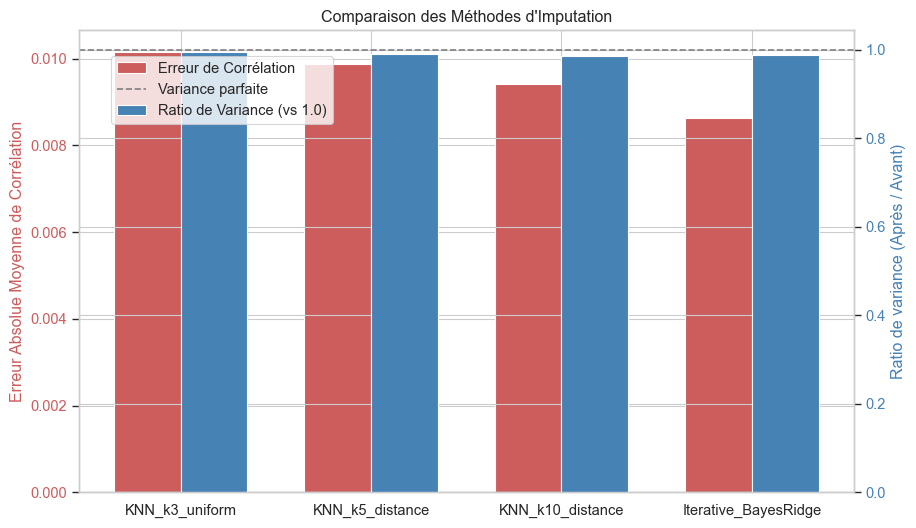

In [67]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(imputers))
width = 0.35

# Barres pour l'erreur de corrélation (axe de gauche)
bars1 = ax1.bar(x - width/2, list(results_corr_error.values()), width, label='Erreur de Corrélation', color='indianred')
ax1.set_ylabel('Erreur Absolue Moyenne de Corrélation', color='indianred')
ax1.tick_params(axis='y', labelcolor='indianred')

# Création d'un second axe Y pour le ratio de variance
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, list(results_var_ratio.values()), width, label='Ratio de Variance (vs 1.0)', color='steelblue')
ax2.set_ylabel('Ratio de variance (Après / Avant)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Ajout d'une ligne de référence parfaite pour la variance
ax2.axhline(1.0, color='gray', linestyle='--', label='Variance parfaite')

ax1.set_xticks(x)
ax1.set_xticklabels(imputers.keys())
ax1.set_title("Comparaison des Méthodes d'Imputation")
fig.legend(loc="upper left", bbox_to_anchor=(0.15,0.85))

plt.show()

Les résultats du benchmark montrent que toutes les méthodes testées préservent assez bien la structure des données, avec des erreurs moyennes de corrélation très faibles (<0.011) et des ratios de variance proches de 1.0. Les variantes du KNN Imputer offrent une performance correcte, mais on observe une légère dégradation de la variance préservée à mesure que le nombre de voisins augmente (de 0.9938 pour k=3 à 0.9855 pour k=10). 

En revanche, l’approche **Iterative Imputer BayesRidge** se distingue par la meilleure préservation des corrélations (0.0086 d’erreur moyenne), tout en maintenant un ratio de variance satisfaisant (0.9872). Cela suggère que, dans ce contexte, les méthodes itératives basées sur des modèles statistiques sont plus adaptées pour conserver la structure multivariée des données, tandis que le KNN reste une solution simple mais légèrement moins robuste lorsqu’on augmente le nombre de voisins.  


In [ ]:
# Sélection  de la meilleure méthode basée sur l'erreur de corrélation
best_method = min(results_corr_error, key=results_corr_error.get)
print(f"\nMéthode optimale sélectionnée : {best_method}")

# Récupération du dataset gagnant
df_final_imputed = imputed_datasets[best_method]

# Réintégration des colonnes d'identification
df_final_imputed.insert(0, 'iso_code', df['iso_code'])
df_final_imputed.insert(0, 'country', df['country'])

# Sauvegarde
processed_dir = paths.DATA_DIR / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
output_path = processed_dir / f"data_imputed_{best_method}.csv"

df_final_imputed.to_csv(output_path, index=False)
print(f"Dataset final sauvegardé sous : {output_path}")


Méthode optimale sélectionnée : Iterative_BayesRidge
Dataset final sauvegardé sous : C:\Users\HP\Desktop\temp\TODO\SEMESTRE_2\ML2\projet\data\processed\data_imputed_Iterative_BayesRidge.csv


### Conclusion

Nous avons retenu une stratégie d’imputation complète afin de garantir la comparabilité des pays et la stabilité des algorithmes de clustering. Les méthodes testées (KNN, BayesRidge) ont montré une bonne préservation des corrélations et variances, ce qui valide la robustesse statistique de l’approche. Toutefois, nous reconnaissons que certaines absences de données (pauvreté, VIH) peuvent être porteuses d’information institutionnelle ou politique. Leur imputation permet une analyse quantitative homogène, mais les résultats doivent être interprétés avec prudence, en gardant à l’esprit que l’absence elle‑même peut refléter une réalité socio‑économique.
> Lors de la modélisation nous examinerons en detaille l'impact de l'imputation (eventuellement avec des variables has_na).